# What Separates Winners? A Data-Driven Analysis of NCAA Division I Men's Basketball (2026)

## Introduction

This notebook analyzes the 2025–26 NCAA Division I men's basketball season using data collected 
from the ESPN API. The dataset spans 362 Division I programs and includes season-level team 
performance, game-by-game results, and individual player roster data.

## Target Audience

This analysis is written for athletic department strategy teams, conference offices, and 
basketball operations staff interested in understanding what measurable factors separate 
winning programs from losing ones across the full D1 landscape.

## Central Question

What separates winning programs in NCAA Division I men's basketball — and can those factors 
be measured, quantified, and used to predict outcomes?

## Approach

The analysis moves from the broad to the specific: starting with the structure of D1 as a 
whole, then narrowing to conference performance, team-level drivers of winning, roster 
composition, and finally predictive modeling of game outcomes and season win rates.

## Data Source

All data was collected via the ESPN Core and Site APIs for the 2025–26 season and processed 
through Snowflake before being loaded here for analysis. The dataset includes:
- **362** Division I teams across **31** conferences
- **11,954** completed team-game records representing **6,292** unique games
- **5,648** individual player roster records

## Section 1: Environment Setup & Data Load

In [272]:
# Uncomment if running in a fresh environment
# ! pip install python-dotenv
# ! pip install snowflake-connector-python[pandas]

from dotenv import load_dotenv
import snowflake.connector
import os
import pandas as pd
import requests

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy import stats

from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.metrics import ( 
    accuracy_score, precision_score, recall_score, f1_score, classification_report, r2_score, 
    mean_absolute_error, mean_squared_error, confusion_matrix, roc_auc_score
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler


In [273]:
load_dotenv()

conn = snowflake.connector.connect(
    user=os.getenv("SNOWFLAKE_USER"),
    password=os.getenv("SNOWFLAKE_PASSWORD"),
    account=os.getenv("SNOWFLAKE_ACCOUNT"),
    warehouse=os.getenv("SNOWFLAKE_WAREHOUSE"),
    database=os.getenv("SNOWFLAKE_DATABASE"),
    schema=os.getenv("SNOWFLAKE_SCHEMA")
)

In [274]:
df_views = pd.read_sql("""
    SELECT table_name 
    FROM information_schema.views 
    WHERE table_schema = CURRENT_SCHEMA()
""", conn)
print(df_views)

C:\Users\Owner\AppData\Local\Temp\ipykernel_24212\2181744936.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_views = pd.read_sql("""


               TABLE_NAME
0         VW_GROUPS_CLEAN
1             VW_D1_TEAMS
2      VW_D1_GAMES_UNIQUE
3   VW_RECORD_STATS_CLEAN
4  VW_TEAM_RECORD_SUMMARY
5             VW_D1_GAMES
6  VW_TEAM_CLASSIFICATION
7          VW_TEAMS_CLEAN
8           VW_D1_PLAYERS


In [275]:
df_d1_teams = pd.read_sql("SELECT * FROM vw_d1_teams", conn)
df_d1_players = pd.read_sql("SELECT * FROM vw_d1_players", conn)
df_d1_games = pd.read_sql("SELECT * FROM vw_d1_games", conn)
df_d1_games_unique = pd.read_sql("SELECT * FROM vw_d1_games_unique", conn)

C:\Users\Owner\AppData\Local\Temp\ipykernel_24212\3584338800.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_d1_teams = pd.read_sql("SELECT * FROM vw_d1_teams", conn)
C:\Users\Owner\AppData\Local\Temp\ipykernel_24212\3584338800.py:2: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_d1_players = pd.read_sql("SELECT * FROM vw_d1_players", conn)
C:\Users\Owner\AppData\Local\Temp\ipykernel_24212\3584338800.py:3: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_d1_games = pd.read_sql("SELECT * FROM vw_d1_games", conn)
C:\

In [276]:
print(f"df_d1_teams:        {df_d1_teams.shape}")
print(f"df_d1_players:      {df_d1_players.shape}")
print(f"df_d1_games:        {df_d1_games.shape}")
print(f"df_d1_games_unique: {df_d1_games_unique.shape}")

df_d1_teams:        (362, 20)
df_d1_players:      (5648, 19)
df_d1_games:        (11986, 16)
df_d1_games_unique: (6309, 11)


The four core tables loaded above form the backbone of this analysis. Teams and players provide 
season-level and roster-level context. Games and unique games provide the game-level outcomes 
used for both EDA and modeling. All views were pre-built and validated in Snowflake before 
being loaded here.

## Section 2: Data Quality

Before drawing any conclusions, we validate the data across all four tables. This section 
checks for missing values, unexpected values, and structural oddities that could affect 
downstream analysis. Any issues found here are addressed before EDA begins.

In [277]:
print(f"Conferences:  {df_d1_teams['CONFERENCE'].nunique()}")
print(f"Divisions:    {df_d1_teams['DIVISION'].nunique()}")
print(f"Positions:    {df_d1_players['POSITION'].nunique()}")
print(f"Home/Away:    {df_d1_games['HOME_AWAY'].nunique()}")
print()
print("Home/Away values:  ", df_d1_games['HOME_AWAY'].unique())
print("Position values:   ", df_d1_players['POSITION'].unique())
print("Division values:   ", df_d1_teams['DIVISION'].unique())

Conferences:  31
Divisions:    1
Positions:    8
Home/Away:    2

Home/Away values:   ['away' 'home']
Position values:    ['G' 'F' 'C' 'PG' 'PF' 'NA' 'SG' 'SF']
Division values:    ['NCAA Division I']


Categorical values are clean — HOME_AWAY contains only "home" and "away", all teams 
map to a single division (NCAA Division I), and all 31 conferences are consistently 
labeled. NEUTRAL_SITE loads as a boolean, while WON loads as an object because some game rows have missing outcomes. After incomplete games are removed, WON is converted to an integer for analysis and modeling.

In [278]:
# dtype check across all four tables
print("--- df_d1_teams ---")
print(df_d1_teams.dtypes)
print("\n--- df_d1_players ---")
print(df_d1_players.dtypes)
print("\n--- df_d1_games ---")
print(df_d1_games.dtypes)
print("\n--- df_d1_games_unique ---")
print(df_d1_games_unique.dtypes)

--- df_d1_teams ---
TEAM_ID          object
SEASON            int64
TEAM_NAME        object
ABBREVIATION     object
LOCATION         object
MASCOT           object
CONFERENCE       object
DIVISION         object
WINS            float64
LOSSES          float64
WIN_PCT         float64
PPG             float64
OPP_PPG         float64
POINT_DIFF      float64
HOME_WINS       float64
HOME_LOSSES     float64
AWAY_WINS       float64
AWAY_LOSSES     float64
CONF_WINS       float64
CONF_LOSSES     float64
dtype: object

--- df_d1_players ---
ATHLETE_ID        object
TEAM_ID           object
SEASON             int64
TEAM_NAME         object
CONFERENCE        object
PLAYER_NAME       object
FIRST_NAME        object
LAST_NAME         object
JERSEY            object
POSITION          object
POSITION_NAME     object
HEIGHT           float64
WEIGHT           float64
YEAR              object
YEARS_EXP        float64
CITY              object
STATE             object
COUNTRY           object
ACTIVE       

The dtype check confirms that the primary numeric columns load correctly. `NEUTRAL_SITE` loads as a boolean, while `WON` loads as an object because some game rows have missing outcomes. After incomplete games are removed, `WON` is converted to an integer for analysis and modeling.

In [279]:
def null_summary(df, name):
    summary = df.isnull().sum().reset_index()
    summary.columns = ["column", "null_count"]
    summary["pct_missing"] = (summary["null_count"] / len(df) * 100).round(2)
    summary = summary[summary["null_count"] > 0].sort_values("pct_missing", ascending=False)
    summary.insert(0, "table", name)
    return summary

pd.concat([
    null_summary(df_d1_teams, "teams"),
    null_summary(df_d1_players, "players"),
    null_summary(df_d1_games, "games"),
    null_summary(df_d1_games_unique, "games_unique")
]).reset_index(drop=True)

,table,column,null_count,pct_missing
0,players,STATE,831,14.71
1,players,WEIGHT,274,4.85
2,players,JERSEY,37,0.66
3,players,HEIGHT,35,0.62
4,players,YEAR,32,0.57
5,players,YEARS_EXP,32,0.57
6,players,CITY,32,0.57
7,players,COUNTRY,32,0.57
8,games,WON,32,0.27


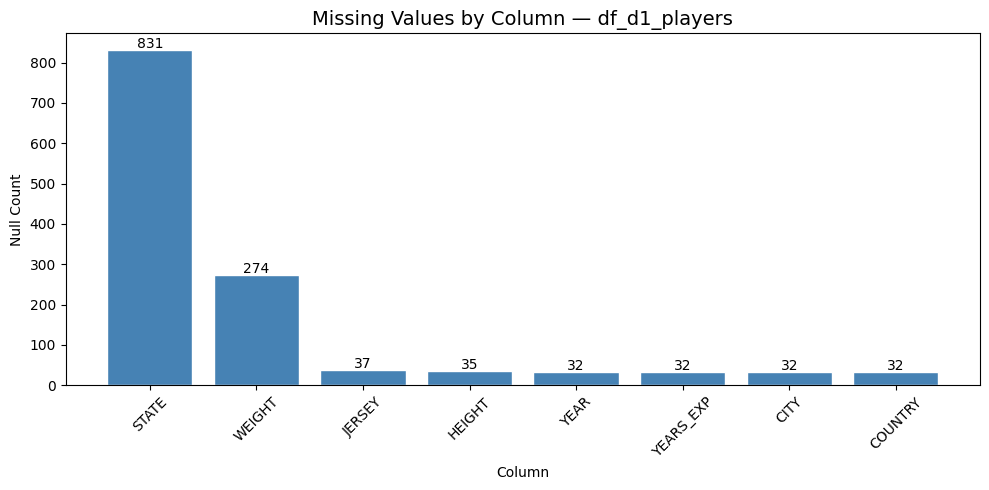

In [280]:
fig, ax = plt.subplots(figsize=(10, 5))

null_counts = df_d1_players.isnull().sum()
null_counts = null_counts[null_counts > 0].sort_values(ascending=False)

ax.bar(null_counts.index, null_counts.values, color="steelblue", edgecolor="white")
ax.set_title("Missing Values by Column — df_d1_players", fontsize=14)
ax.set_xlabel("Column")
ax.set_ylabel("Null Count")
ax.tick_params(axis="x", rotation=45)

for i, v in enumerate(null_counts.values):
    ax.text(i, v + 5, str(v), ha="center", fontsize=10)

plt.tight_layout()
plt.show()

The chart confirms that missing data is concentrated in a small number of player 
attributes — STATE, WEIGHT, and JERSEY — while all team and game records are complete.

In [281]:
# Check if missing state is just international players
df_d1_players[df_d1_players["STATE"].isnull()]["COUNTRY"].value_counts().head(10)

COUNTRY
France         62
Nigeria        44
Senegal        41
Serbia         39
Germany        37
England        35
Spain          32
Lithuania      28
New Zealand    22
Italy          21
Name: count, dtype: int64

The missing STATE values are almost entirely international players — France, Nigeria, 
Senegal, Serbia, and Germany lead the list. This confirms that STATE nulls are not a 
data quality issue but a natural consequence of the dataset including international 
recruits for whom a US state is not applicable.

In [282]:
print("Teams with 0 wins:")
print(df_d1_teams[df_d1_teams["WINS"] == 0][["TEAM_NAME", "CONFERENCE", "WINS", "LOSSES"]])

print("\nTeams with PPG below 50 or above 110:")
print(df_d1_teams[(df_d1_teams["PPG"] < 50) | (df_d1_teams["PPG"] > 110)][["TEAM_NAME", "PPG", "WINS"]])

print("\nGames with score of 0:")
print(df_d1_games[(df_d1_games["TEAM_SCORE"] == 0) | (df_d1_games["OPP_SCORE"] == 0)].shape[0])

Teams with 0 wins:
Empty DataFrame
Columns: [TEAM_NAME, CONFERENCE, WINS, LOSSES]
Index: []

Teams with PPG below 50 or above 110:
Empty DataFrame
Columns: [TEAM_NAME, PPG, WINS]
Index: []

Games with score of 0:
32


In [283]:
df_d1_games[df_d1_games["WON"].isnull()]["GAME_ID"].nunique()

17

ESPN returned 17 unique games (32 team-game rows) with no win/loss result — these are 
incomplete records where scores were not finalized in the API. These games are removed 
before analysis to ensure all outcome-based metrics are based on completed games only.

In [284]:
df_d1_games = df_d1_games[df_d1_games["WON"].notnull()].copy()
df_d1_games.shape

(11954, 16)

In [285]:
played_game_ids = df_d1_games["GAME_ID"].unique()
df_d1_games_unique = df_d1_games_unique[df_d1_games_unique["GAME_ID"].isin(played_game_ids)].copy()
df_d1_games_unique.shape

(6292, 11)

Before moving into analysis, we check for statistical outliers using the IQR method 
across key team performance metrics. The goal is to understand whether extreme values 
represent data errors or genuine program-level variation that should be preserved in 
the analysis.

In [286]:
outlier_cols = ["WIN_PCT", "PPG", "OPP_PPG", "POINT_DIFF"]

for col in outlier_cols:
    Q1 = df_d1_teams[col].quantile(0.25)
    Q3 = df_d1_teams[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = df_d1_teams[(df_d1_teams[col] < lower) | (df_d1_teams[col] > upper)]
    print(f"{col}: {len(outliers)} outliers (lower: {lower:.2f}, upper: {upper:.2f})")
    if len(outliers) > 0:
        print(outliers[["TEAM_NAME", col]].to_string())
    print()

WIN_PCT: 0 outliers (lower: 0.07, upper: 0.96)

PPG: 1 outliers (lower: 61.05, upper: 90.35)
                TEAM_NAME   PPG
158  Alabama Crimson Tide  91.2

OPP_PPG: 2 outliers (lower: 60.87, upper: 87.22)
                   TEAM_NAME   OPP_PPG
42   IU Indianapolis Jaguars  88.28125
270    North Florida Ospreys  88.15625

POINT_DIFF: 9 outliers (lower: -13.75, upper: 17.05)
                                 TEAM_NAME  POINT_DIFF
61                     Michigan Wolverines        17.8
64                        Kansas City Roos       -14.6
69                        Duke Blue Devils        18.0
169                      Air Force Falcons       -18.4
196                    Coppin State Eagles       -14.9
215          Gardner-Webb Runnin' Bulldogs       -17.4
218                       Gonzaga Bulldogs        18.1
221                    High Point Panthers        18.4
250  Mississippi Valley State Delta Devils       -18.8



The outlier check confirms that extreme values represent real programs at the edges of 
D1, not data errors. Alabama's 91.2 PPG is the only scoring outlier, reflecting an unusually high-scoring profile relative to the rest of D1. The point differential outliers are the division's best (Michigan, Duke, Gonzaga, High Point) and worst (Mississippi Valley State, Air Force, 
Gardner-Webb) programs. None are removed — they are genuine performance extremes that 
are central to understanding what separates D1's best from its worst.

### Data Quality Summary

The data quality checks confirm the dataset is clean and ready for analysis:

- **No missing values** in teams or unique games tables
- **Player nulls are expected** — missing weight (4.9%), state (14.7%), and height (<1%) 
  reflect incomplete ESPN roster data, concentrated in smaller programs and international 
  players. These fields are not used as primary analysis inputs.
- **32 incomplete games identified and removed** — ESPN returned a score of 0 and no 
  win/loss result for 17 unique games (32 team-game rows). These were filtered before analysis, leaving 11,954 completed team-game records representing 6,292 unique games.
- **No structural oddities** — no teams with zero wins and no impossible scoring values 
  in the completed game set
- **Categorical values are clean** — HOME_AWAY contains only "home" and "away", 
  all teams map to a single division (NCAA Division I), and all 31 conferences 
  are consistently labeled

## Section 3: The D1 Landscape

With a clean dataset in hand, we start broad. This section establishes what NCAA Division I 
men's basketball looks like structurally in 2026 — how the division is organized across 
conferences, how competitive the field is, and what the scoring environment looks like 
league-wide. This context is essential before asking which teams and conferences perform best.

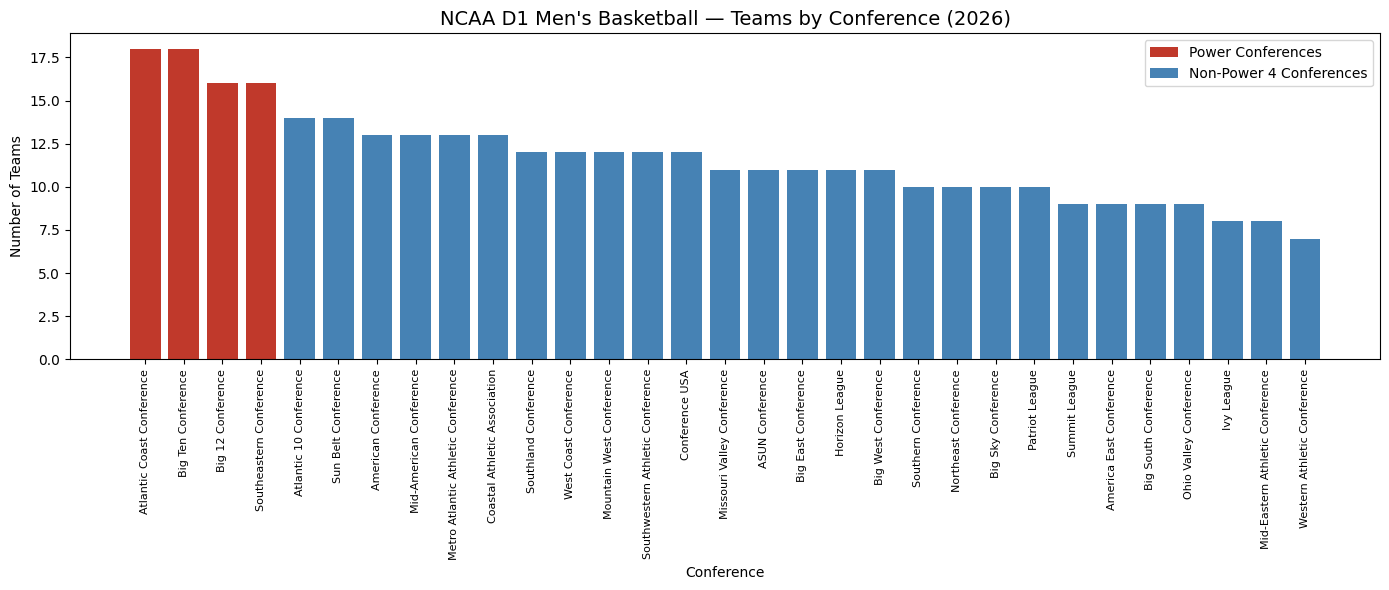

In [287]:
# Teams per conference
conf_counts = df_d1_teams.groupby("CONFERENCE")["TEAM_ID"].count().sort_values(ascending=False).reset_index()
conf_counts.columns = ["conference", "team_count"]

power_conferences = ["Atlantic Coast Conference", "Big Ten Conference", "Big 12 Conference", "Southeastern Conference"]

colors = ["#c0392b" if c in power_conferences else "steelblue" for c in conf_counts["conference"]]

fig, ax = plt.subplots(figsize=(14, 6))
bars = ax.bar(conf_counts["conference"], conf_counts["team_count"], color=colors)

ax.set_title("NCAA D1 Men's Basketball — Teams by Conference (2026)", fontsize=14)
ax.set_xlabel("Conference")
ax.set_ylabel("Number of Teams")
ax.tick_params(axis="x", rotation=90, labelsize=8)

# Legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor="#c0392b", label="Power Conferences"),
                   Patch(facecolor="steelblue", label="Non-Power 4 Conferences")]
ax.legend(handles=legend_elements)

plt.tight_layout()
plt.show()

D1 spans 31 conferences ranging from 7 to 18 teams. The four power conferences — ACC, 
Big 12, Big Ten, and SEC — are highlighted in red. While they don't differ dramatically in size from other D1 conferences, their resource advantages and recruiting footprints make them 
structurally distinct from the rest of the field.

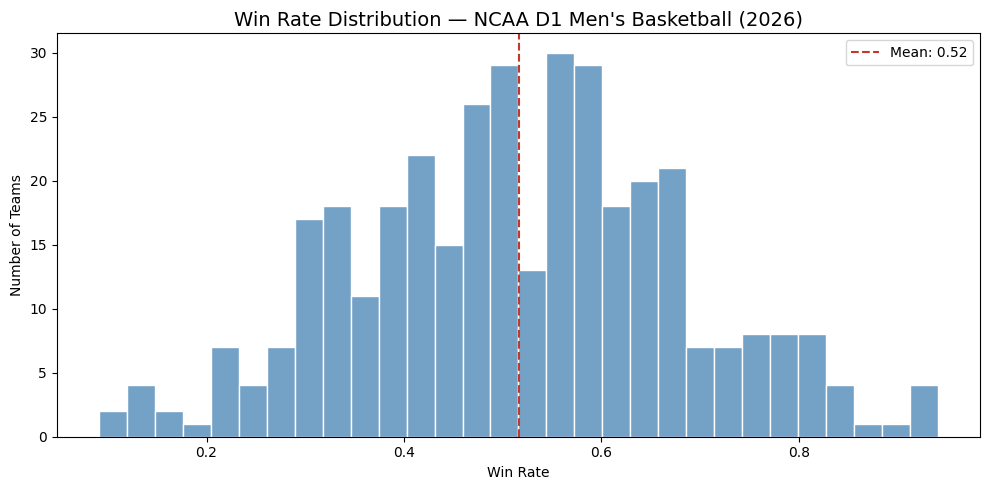

In [288]:
fig, ax = plt.subplots(figsize=(10, 5))
sns.histplot(df_d1_teams["WIN_PCT"], bins=30, color="steelblue", edgecolor="white", ax=ax)
ax.axvline(df_d1_teams["WIN_PCT"].mean(), color="#c0392b", linestyle="--", linewidth=1.5, label=f"Mean: {df_d1_teams['WIN_PCT'].mean():.2f}")
ax.set_title("Win Rate Distribution — NCAA D1 Men's Basketball (2026)", fontsize=14)
ax.set_xlabel("Win Rate")
ax.set_ylabel("Number of Teams")
ax.legend()
plt.tight_layout()
plt.show()

Win rate across D1 follows a roughly normal distribution centered at 0.52. The slight 
rightward skew reflects a small group of elite programs pulling the mean above 0.50. 
The spread from near 0.10 to 0.95 confirms meaningful variation in program quality 
across the division.

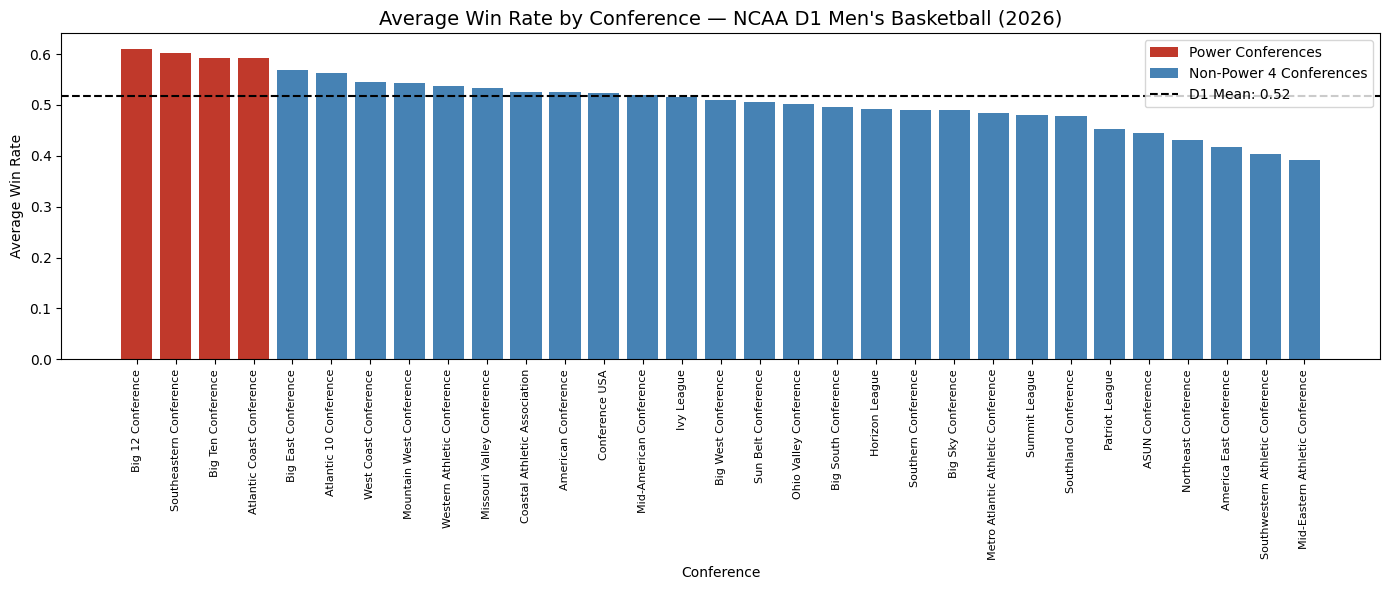

In [289]:
conf_wins = df_d1_teams.groupby("CONFERENCE")["WIN_PCT"].mean().sort_values(ascending=False).reset_index()
conf_wins.columns = ["conference", "avg_win_pct"]

power_conferences = ["Atlantic Coast Conference", "Big Ten Conference", "Big 12 Conference", "Southeastern Conference"]
colors = ["#c0392b" if c in power_conferences else "steelblue" for c in conf_wins["conference"]]

fig, ax = plt.subplots(figsize=(14, 6))
ax.bar(conf_wins["conference"], conf_wins["avg_win_pct"], color=colors)
ax.axhline(df_d1_teams["WIN_PCT"].mean(), color="black", linestyle="--", linewidth=1.5, label=f"D1 Mean: {df_d1_teams['WIN_PCT'].mean():.2f}")
ax.set_title("Average Win Rate by Conference — NCAA D1 Men's Basketball (2026)", fontsize=14)
ax.set_xlabel("Conference")
ax.set_ylabel("Average Win Rate")
ax.tick_params(axis="x", rotation=90, labelsize=8)

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor="#c0392b", label="Power Conferences"),
                   Patch(facecolor="steelblue", label="Non-Power 4 Conferences"),
                   plt.Line2D([0], [0], color="black", linestyle="--", label=f"D1 Mean: {df_d1_teams['WIN_PCT'].mean():.2f}")]
ax.legend(handles=legend_elements)

plt.tight_layout()
plt.show()

The four power conferences — Big 12, SEC, ACC, and Big Ten — all sit above the D1 mean 
win rate of 0.52, suggesting that structural advantages in recruiting, resources, and conference context are associated with stronger on-court results. The Big 12 leads at 0.61, notable given its recent expansion. Conferences outside the Power 4, especially basketball-heavy leagues like the Big East and Atlantic 10, remain highly competitive but the drop-off below the mean accelerates toward the smaller conferences at the bottom of the division.

To formally quantify the Power 4 vs. rest-of-D1 distinction throughout the analysis, we engineer 
a binary flag identifying the four power conferences. This feature will appear in our 
correlation analysis and predictive models, allowing us to test whether conference 
membership adds explanatory power beyond what performance metrics alone capture.

In [290]:
power_conferences = [
    "Atlantic Coast Conference", "Big Ten Conference",
    "Big 12 Conference", "Southeastern Conference"
]
df_d1_teams["IS_POWER_CONF"] = df_d1_teams["CONFERENCE"].isin(power_conferences).astype(int)

print(f"Power conference teams: {df_d1_teams['IS_POWER_CONF'].sum()}")
print(f"Non-Power 4 teams: {(df_d1_teams['IS_POWER_CONF'] == 0).sum()}")

Power conference teams: 68
Non-Power 4 teams: 294


For this analysis, IS_POWER_CONF identifies teams in the ACC, Big Ten, Big 12, and SEC. This is a simplified structural grouping intended to capture broad resource and conference-context differences; it does not perfectly represent basketball-specific conference strength.

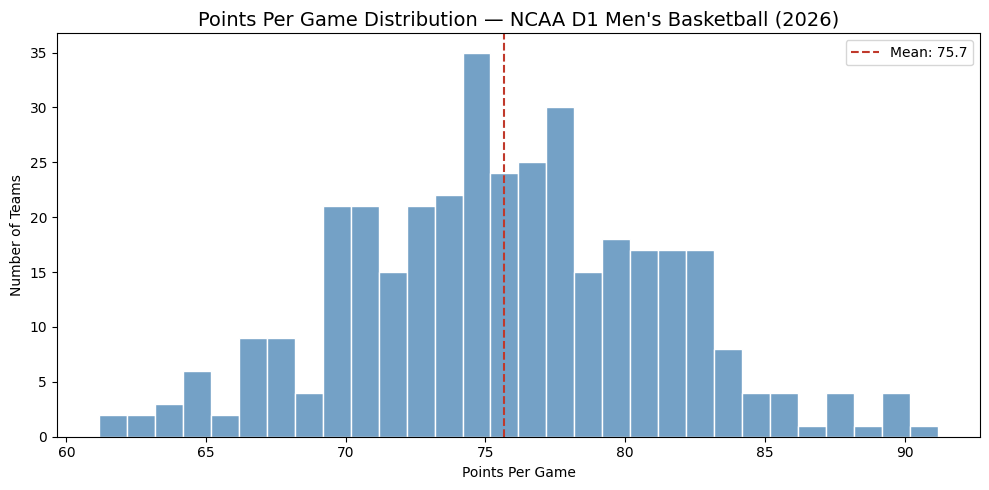

In [291]:
fig, ax = plt.subplots(figsize=(10, 5))
sns.histplot(df_d1_teams["PPG"], bins=30, color="steelblue", edgecolor="white", ax=ax)
ax.axvline(df_d1_teams["PPG"].mean(), color="#c0392b", linestyle="--", linewidth=1.5, label=f"Mean: {df_d1_teams['PPG'].mean():.1f}")
ax.set_title("Points Per Game Distribution — NCAA D1 Men's Basketball (2026)", fontsize=14)
ax.set_xlabel("Points Per Game")
ax.set_ylabel("Number of Teams")
ax.legend()
plt.tight_layout()
plt.show()

Scoring across D1 is tightly clustered between 70 and 82 points per game, with a mean 
of 75.5. The distribution is roughly normal with a slight right tail driven by a small 
group of high-tempo programs. Very few teams average below 65 or above 90, suggesting 
the scoring environment is relatively consistent across the division.

In [292]:
conf_summary = df_d1_teams.groupby("CONFERENCE")[["WIN_PCT", "PPG", "OPP_PPG", "POINT_DIFF"]].mean().round(2).sort_values("WIN_PCT", ascending=False)
conf_summary.index.name = "Conference"
conf_summary.columns = ["Avg Win Rate", "Avg PPG", "Avg Opp PPG", "Avg Point Diff"]
conf_summary

,Avg Win Rate,Avg PPG,Avg Opp PPG,Avg Point Diff
Conference,,,,
Big 12 Conference,0.61,78.85,73.58,5.28
Southeastern Conference,0.60,82.93,77.11,5.82
Atlantic Coast Conference,0.59,77.88,73.02,4.88
Big Ten Conference,0.59,76.83,72.15,4.68
Big East Conference,0.57,76.56,73.36,3.23
Atlantic 10 Conference,0.56,74.78,71.34,3.42
West Coast Conference,0.55,75.55,72.71,2.83
Western Athletic Conference,0.54,74.40,71.90,2.47
Mountain West Conference,0.54,75.77,73.32,2.44


The SEC stands out as the highest-scoring conference at 82.93 PPG despite ranking second 
in win rate — suggesting an up-tempo style relative to the rest of D1. The Big 12 wins 
more while scoring less, pointing to a more defense-oriented identity. Point differential tells a cleaner story than win rate alone: the gap between Power 4 and non-Power 4 conferences widens when measured by margin rather than just record.

In [293]:
df_d1_teams[["WINS", "LOSSES", "WIN_PCT", "PPG", "OPP_PPG", "POINT_DIFF"]].describe().round(2)

,WINS,LOSSES,WIN_PCT,PPG,OPP_PPG,POINT_DIFF
count,362.00,362.00,362.00,362.00,362.00,362.00
mean,17.26,15.76,0.52,75.67,74.01,1.66
std,6.18,5.00,0.16,5.52,4.71,6.32
min,3.00,2.00,0.09,61.16,61.75,-18.80
25%,13.00,12.00,0.40,72.04,70.75,-2.20
50%,17.00,16.00,0.52,75.42,73.95,1.80
75%,21.00,19.00,0.62,79.36,77.34,5.50
max,37.00,30.00,0.94,91.20,88.28,18.40


The summary statistics reinforce the breadth of the D1 field. The average team wins 52% of games and scores 75.7 points per game. Win rate ranges from 0.09 to 0.94, point differential spans from -18.8 to +18.4, and PPG ranges from 61 to 91. The interquartile range for win rate runs from 0.40 to 0.62, meaning the middle 50% of D1 programs are relatively clustered around average performance, while the tails show meaningful separation between the division’s strongest and weakest programs.

## Section 4: What Separates Winners?

The landscape section established that D1 is a wide field with meaningful variation in 
team quality. The next question is: what actually drives that variation? This section 
examines the performance metrics most strongly associated with winning — starting with 
scoring margin, then layering in conference context, home court advantage, and the 
relationship between offense and defense. The goal is to identify which measurable factors 
best explain why some programs win consistently and others don't.

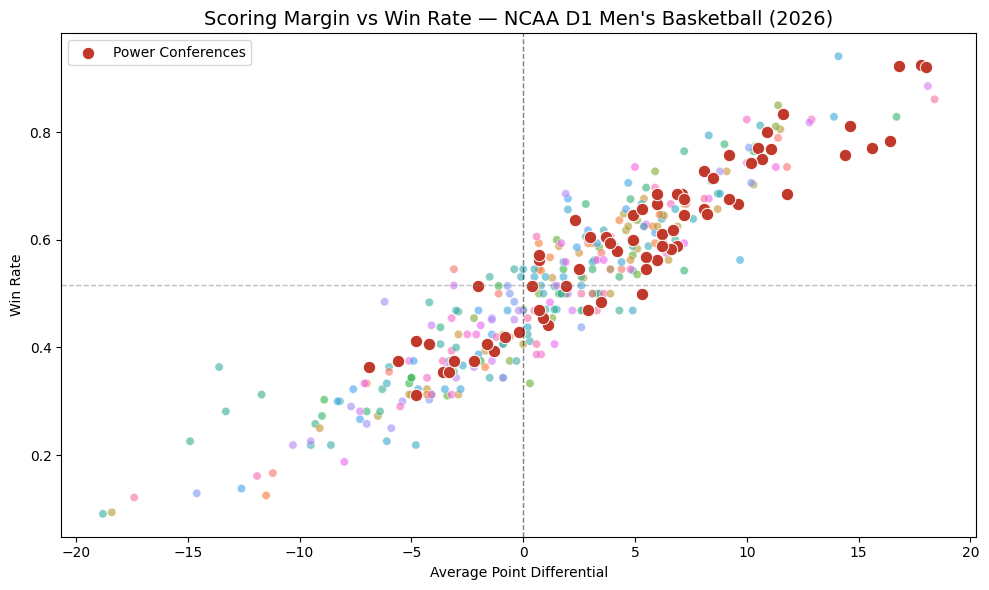

In [294]:
fig, ax = plt.subplots(figsize=(10, 6))
sns.scatterplot(data=df_d1_teams, x="POINT_DIFF", y="WIN_PCT", 
                hue="CONFERENCE", legend=False, alpha=0.6, ax=ax)

# Add power conference teams as highlighted points
power_conferences = ["Atlantic Coast Conference", "Big Ten Conference", "Big 12 Conference", "Southeastern Conference"]
power_teams = df_d1_teams[df_d1_teams["CONFERENCE"].isin(power_conferences)]
sns.scatterplot(data=power_teams, x="POINT_DIFF", y="WIN_PCT",
                color="#c0392b", label="Power Conferences", s=80, ax=ax)

ax.axvline(0, color="black", linestyle="--", linewidth=1, alpha=0.5)
ax.axhline(df_d1_teams["WIN_PCT"].mean(), color="gray", linestyle="--", linewidth=1, alpha=0.5)
ax.set_title("Scoring Margin vs Win Rate — NCAA D1 Men's Basketball (2026)", fontsize=14)
ax.set_xlabel("Average Point Differential")
ax.set_ylabel("Win Rate")
ax.legend()
plt.tight_layout()
plt.show()

The relationship between point differential and win rate is nearly linear across all 362 
D1 programs. Teams with a positive scoring margin almost universally win more than half 
their games, and teams with a negative margin do the opposite. There are very few exceptions 
— the quadrants are clean. Power conference teams cluster in the upper right, winning by 
large margins consistently, while the bottom of the division sits in the lower left. This 
single metric — how much you win or lose by — tracks season success more closely than 
almost anything else we can measure.

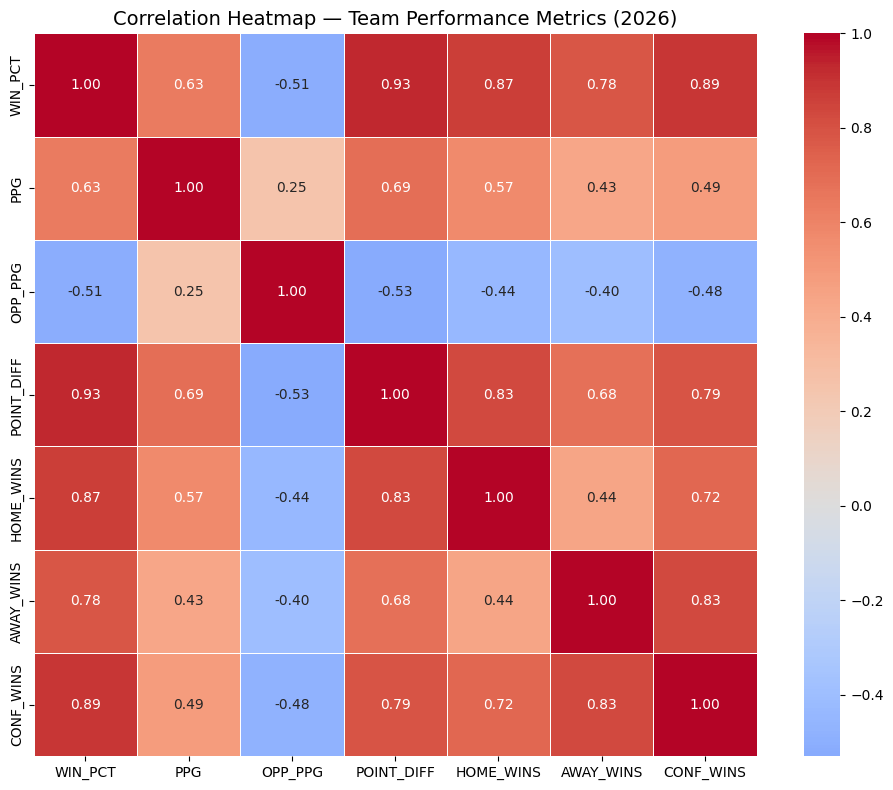

In [295]:
corr_cols = ["WIN_PCT", "PPG", "OPP_PPG", "POINT_DIFF", "HOME_WINS", "AWAY_WINS", "CONF_WINS"]
corr_matrix = df_d1_teams[corr_cols].corr().round(2)

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", 
            center=0, square=True, linewidths=0.5, ax=ax)
ax.set_title("Correlation Heatmap — Team Performance Metrics (2026)", fontsize=14)
plt.tight_layout()
plt.show()

The correlation heatmap quantifies what the scatter plot showed visually. Key takeaways:

- **Point differential (0.93)** is the strongest predictor of win rate — stronger than 
  any individual component
- **Home wins (0.87) and conference wins (0.89)** are highly correlated with overall 
  win rate, reflecting that teams that win at home and in conference tend to win overall
- **Away wins (0.78)** have a lower correlation than home wins, consistent with the 
  home court advantage finding — road wins are harder to accumulate and less predictable
- **PPG (0.63) vs OPP_PPG (-0.51)** — offense and defense both matter, but offense 
  correlates more strongly with winning than defense does in this dataset
- **PPG and OPP_PPG are positively correlated (0.25)** — high-scoring teams also tend 
  to give up more points, suggesting pace of play affects both sides of the ball equally

The dominant signal is clear: winning by more points, more consistently, across all 
game contexts is what separates D1's best programs from the rest.

The heatmap confirms that PPG and OPP_PPG both correlate with winning, but neither 
captures the full picture alone — a team scoring 90 and allowing 85 looks very different 
from one scoring 70 and allowing 65, yet both have similar raw stats. We engineer a 
scoring efficiency ratio — points scored divided by points allowed — to capture both 
offensive and defensive quality in a single metric. A value above 1.0 means a team 
outscores its opponents on average.

In [296]:
df_d1_teams["SCORING_EFFICIENCY"] = (df_d1_teams["PPG"] / df_d1_teams["OPP_PPG"]).round(3)

df_d1_teams[["TEAM_NAME", "PPG", "OPP_PPG", "SCORING_EFFICIENCY", "WIN_PCT"]]\
    .sort_values("SCORING_EFFICIENCY", ascending=False).head(10)

,TEAM_NAME,PPG,OPP_PPG,SCORING_EFFICIENCY,WIN_PCT
69,Duke Blue Devils,81.63158,63.631580,1.283,0.921053
218,Gonzaga Bulldogs,84.28571,66.171425,1.274,0.885714
221,High Point Panthers,89.72222,71.250000,1.259,0.861111
61,Michigan Wolverines,87.32500,69.500000,1.256,0.925000
34,Iowa State Cyclones,81.97298,65.621620,1.249,0.783784
5,Arizona Wildcats,86.15385,69.384610,1.242,0.923077
63,Saint Louis Billikens,87.22857,70.457146,1.238,0.828571
114,Houston Cougars,76.86487,62.324326,1.233,0.810811
29,Florida Gators,87.14286,71.542854,1.218,0.771429
164,Illinois Fighting Illini,83.21622,68.756760,1.210,0.756757


The top scoring efficiency programs — Arizona (1.242), Duke (1.283), Michigan (1.256) — 
are the same programs dominating the win rate rankings, suggesting this engineered 
feature captures program quality more precisely than raw scoring alone. With a correlation 
of 0.94 with win rate, scoring efficiency is the single strongest predictor we have 
identified so far.

In [297]:
df_d1_games["WON"] = df_d1_games["WON"].astype(int)
df_d1_games["LOCATION"] = df_d1_games.apply(
    lambda row: "Neutral" if row["NEUTRAL_SITE"] == True else row["HOME_AWAY"].capitalize(), axis=1
)

location_summary = df_d1_games.groupby("LOCATION")["WON"].mean().round(3).reset_index()
location_summary.columns = ["Location", "Win Rate"]
location_summary

,Location,Win Rate
0,Away,0.356
1,Home,0.679
2,Neutral,0.502


Home court advantage is one of the most consistent findings in the data. Home teams win 67.9% of games, while away teams win only 35.6% — a 32.3 percentage point gap. Neutral-site games are much closer to evenly split, with teams winning 50.2% of neutral-site matchups from the team-row perspective. This suggests that game location is an important contextual factor in team outcomes, which is why it is included as a feature in the predictive models in Section 7.

The aggregate home/away/neutral split reveals the structural advantage of home court, 
but it treats all teams equally. To understand which programs are best at winning in 
each context — and to create more precise model inputs — we decompose overall win rate 
into three situational metrics: home win rate, away win rate, and conference win rate. 
Away win rate is particularly meaningful since road wins are harder to accumulate and 
more predictive of true program quality than home wins alone.

In [298]:
df_d1_teams["HOME_WIN_PCT"] = (df_d1_teams["HOME_WINS"] /
    (df_d1_teams["HOME_WINS"] + df_d1_teams["HOME_LOSSES"])).round(3)

df_d1_teams["AWAY_WIN_PCT"] = (df_d1_teams["AWAY_WINS"] /
    (df_d1_teams["AWAY_WINS"] + df_d1_teams["AWAY_LOSSES"])).round(3)

df_d1_teams["CONF_WIN_PCT"] = (df_d1_teams["CONF_WINS"] /
    (df_d1_teams["CONF_WINS"] + df_d1_teams["CONF_LOSSES"])).round(3)

df_d1_teams[["TEAM_NAME", "WIN_PCT", "HOME_WIN_PCT", "AWAY_WIN_PCT", "CONF_WIN_PCT"]]\
    .sort_values("AWAY_WIN_PCT", ascending=False).head(10)

,TEAM_NAME,WIN_PCT,HOME_WIN_PCT,AWAY_WIN_PCT,CONF_WIN_PCT
61,Michigan Wolverines,0.925000,0.933,1.000,0.950
89,Miami (OH) RedHawks,0.941176,1.000,1.000,1.000
69,Duke Blue Devils,0.921053,1.000,0.909,0.944
309,St. John's Red Storm,0.810811,0.900,0.900,0.900
5,Arizona Wildcats,0.923077,0.941,0.900,0.889
163,UNC Wilmington Seahawks,0.794118,0.789,0.857,0.833
1,UAB Blazers,0.625000,0.471,0.833,0.611
218,Gonzaga Bulldogs,0.885714,1.000,0.800,0.889
29,Florida Gators,0.771429,0.933,0.800,0.889
311,Saint Mary's Gaels,0.818182,1.000,0.800,0.889


Sorting by away win rate reveals a different set of elite programs than sorting by 
overall win rate — teams that win on the road consistently are demonstrating a quality 
advantage that home-heavy records can mask. These three context-specific rates will 
serve as features in our predictive models alongside scoring efficiency and point 
differential.

## Section 5: The AP Rankings Lens

The analysis so far has treated all 362 D1 teams equally. To validate our performance 
metrics against an established external benchmark, we bring in the 2025–26 AP Top 25 
poll rankings. The AP poll represents the consensus view of college basketball analysts 
and voters — if our metrics are meaningful, ranked teams should look materially different 
from unranked teams across every dimension we have measured so far.

In [299]:
# pull AP Top 25 rankings from ESPN API for the 2025-26 season
rankings_raw = requests.get(
    "https://site.api.espn.com/apis/site/v2/sports/basketball/mens-college-basketball/rankings",
    params={"season": 2026, "seasontype": 3}
).json()

# find the AP Top 25 poll in the response
ap_poll = next(
    p for p in rankings_raw["rankings"]
    if "AP" in p["name"]
)

# extract team id and rank
ap_rows = []
for entry in ap_poll["ranks"]:
    ap_rows.append({
        "TEAM_ID": str(entry["team"]["id"]),
        "AP_RANK": entry["current"],
        "AP_POINTS": entry.get("points")
    })

ap_df = pd.DataFrame(ap_rows)
print(f"AP poll teams: {len(ap_df)}")
ap_df.head()

AP poll teams: 25


,TEAM_ID,AP_RANK,AP_POINTS
0,130,1,1425.0
1,41,2,1352.0
2,12,3,1311.0
3,150,4,1237.0
4,356,5,1228.0


In [300]:
df_d1_teams["TEAM_ID"] = df_d1_teams["TEAM_ID"].astype(str)
df_d1_teams = df_d1_teams.merge(ap_df, on="TEAM_ID", how="left")
df_d1_teams["IS_RANKED"] = df_d1_teams["AP_RANK"].notna().astype(int)

print(f"AP ranked teams matched: {df_d1_teams['IS_RANKED'].sum()}")
df_d1_teams[df_d1_teams["IS_RANKED"] == 1][["TEAM_NAME", "CONFERENCE", "WINS", "WIN_PCT", "AP_RANK"]].sort_values("AP_RANK")

AP ranked teams matched: 25


,TEAM_NAME,CONFERENCE,WINS,WIN_PCT,AP_RANK
61,Michigan Wolverines,Big Ten Conference,37.0,0.925000,1.0
18,UConn Huskies,Big East Conference,34.0,0.850000,2.0
5,Arizona Wildcats,Big 12 Conference,36.0,0.923077,3.0
69,Duke Blue Devils,Atlantic Coast Conference,35.0,0.921053,4.0
164,Illinois Fighting Illini,Big Ten Conference,28.0,0.756757,5.0
285,Purdue Boilermakers,Big Ten Conference,30.0,0.769231,6.0
114,Houston Cougars,Big 12 Conference,30.0,0.810811,7.0
34,Iowa State Cyclones,Big 12 Conference,29.0,0.783784,8.0
29,Florida Gators,Southeastern Conference,27.0,0.771429,9.0
309,St. John's Red Storm,Big East Conference,30.0,0.810811,10.0


In [301]:
ranked_summary = df_d1_teams.groupby("IS_RANKED")[["WIN_PCT", "PPG", "OPP_PPG", "POINT_DIFF"]].mean().round(3)
ranked_summary.index = ["Unranked", "AP Ranked"]
ranked_summary.columns = ["Avg Win Rate", "Avg PPG", "Avg Opp PPG", "Avg Point Diff"]
ranked_summary

,Avg Win Rate,Avg PPG,Avg Opp PPG,Avg Point Diff
Unranked,0.498,75.196,74.284,0.91
AP Ranked,0.769,82.053,70.337,11.72


The AP rankings serve as an external validation of our performance metrics. Ranked teams 
average a 0.769 win rate compared to 0.498 for unranked programs — a 27 percentage point 
gap. The separation is equally clear in scoring margin: ranked teams outscore opponents 
by an average of +11.72 points per game versus +0.91 for unranked teams. Ranked teams 
also score significantly more (82.05 PPG vs 75.20 PPG) while giving up far fewer points 
(70.34 vs 74.28). This suggests that the performance metrics analyzed throughout this notebook align closely with how the sport's experts evaluate team quality — the AP poll and our data tell the same story.

## Section 6: Roster Composition

The previous sections established that scoring margin, conference strength, and home court 
advantage are the primary drivers of winning at the team level. This section shifts the 
lens to the roster — examining how player-level characteristics like position, physical 
profile, and experience relate to team success. The central question is whether roster 
construction measurably separates winning programs from losing ones.

In [302]:
position_map = {
    "G": "Guard",
    "F": "Forward", 
    "C": "Center",
    "PG": "Guard",
    "SG": "Guard",
    "SF": "Forward",
    "PF": "Forward",
    "NA": "Unknown"
}

df_d1_players["POSITION_FULL"] = df_d1_players["POSITION"].map(position_map)
df_d1_players["POSITION_FULL"].value_counts()

POSITION_FULL
Guard      3331
Forward    1993
Center      311
Unknown      13
Name: count, dtype: int64

In [303]:
df_d1_players_clean = df_d1_players[df_d1_players["POSITION_FULL"] != "Unknown"].copy()

position_summary = df_d1_players_clean.groupby("POSITION_FULL").agg(
    player_count=("ATHLETE_ID", "count"),
    avg_height=("HEIGHT", "mean"),
    avg_weight=("WEIGHT", "mean"),
    avg_experience=("YEARS_EXP", "mean")
).round(2).sort_values("player_count", ascending=False)

position_summary

,player_count,avg_height,avg_weight,avg_experience
POSITION_FULL,,,,
Guard,3331,75.33,189.6,2.55
Forward,1993,80.20,219.7,2.59
Center,311,83.13,241.4,2.61


D1 rosters are guard-heavy by design — 3,331 guards make up 59% of all rostered players, 
followed by 1,993 forwards (35%) and 311 centers (6%). The physical differences by position 
are intuitive: centers average 6'11" and 241 lbs while guards average 6'3" and 190 lbs. 
Experience is nearly identical across all three positions at roughly 2.6 years, suggesting 
roster turnover is uniform regardless of position.

In [304]:
team_experience = df_d1_players_clean.groupby("TEAM_NAME")["YEARS_EXP"].mean().round(2).reset_index()
team_experience.columns = ["TEAM_NAME", "avg_experience"]

df_teams_exp = df_d1_teams.merge(team_experience, on="TEAM_NAME", how="left")

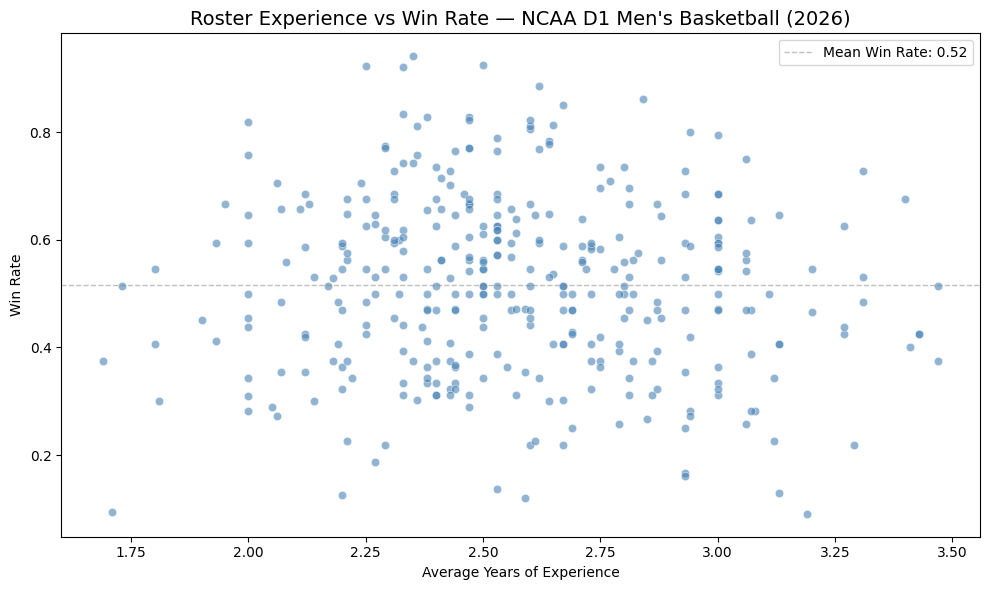

In [305]:
fig, ax = plt.subplots(figsize=(10, 6))
sns.scatterplot(data=df_teams_exp, x="avg_experience", y="WIN_PCT",
                alpha=0.6, color="steelblue", ax=ax)

ax.axhline(df_teams_exp["WIN_PCT"].mean(), color="gray", linestyle="--", linewidth=1, alpha=0.5, label=f"Mean Win Rate: {df_teams_exp['WIN_PCT'].mean():.2f}")
ax.set_title("Roster Experience vs Win Rate — NCAA D1 Men's Basketball (2026)", fontsize=14)
ax.set_xlabel("Average Years of Experience")
ax.set_ylabel("Win Rate")
ax.legend()
plt.tight_layout()
plt.show()

In [306]:
corr = df_teams_exp[["WIN_PCT", "avg_experience"]].corr().round(3)
corr

,WIN_PCT,avg_experience
WIN_PCT,1.000,-0.071
avg_experience,-0.071,1.000


The correlation between roster experience and win rate is -0.071 — effectively zero. 
The scatter confirms this visually: elite programs appear across the full range of 
experience levels. This suggests that average roster experience alone does not explain winning. More detailed player-level production, recruiting rankings, transfer history, and minutes-played data would be needed to determine whether talent acquisition matters more than roster continuity.

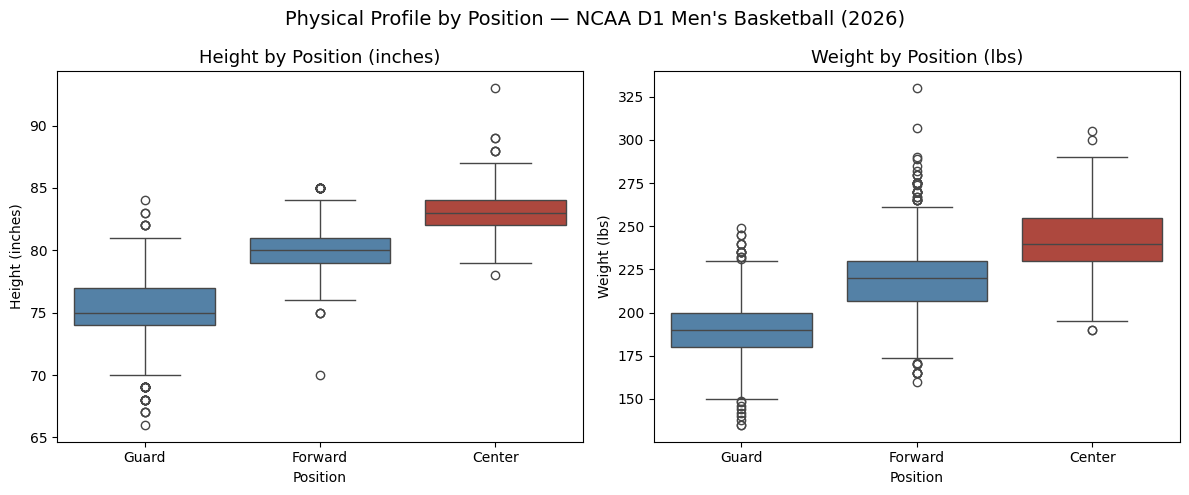

In [307]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.boxplot(data=df_d1_players_clean, x="POSITION_FULL", y="HEIGHT",
            order=["Guard", "Forward", "Center"],
            hue="POSITION_FULL", palette=["steelblue", "steelblue", "#c0392b"],
            legend=False, ax=axes[0])
axes[0].set_title("Height by Position (inches)", fontsize=13)
axes[0].set_xlabel("Position")
axes[0].set_ylabel("Height (inches)")

sns.boxplot(data=df_d1_players_clean, x="POSITION_FULL", y="WEIGHT",
            order=["Guard", "Forward", "Center"],
            hue="POSITION_FULL", palette=["steelblue", "steelblue", "#c0392b"],
            legend=False, ax=axes[1])
axes[1].set_title("Weight by Position (lbs)", fontsize=13)
axes[1].set_xlabel("Position")
axes[1].set_ylabel("Weight (lbs)")

plt.suptitle("Physical Profile by Position — NCAA D1 Men's Basketball (2026)", fontsize=14)
plt.tight_layout()
plt.show()

The physical separation between positions is clear and consistent. Centers are 
significantly taller and heavier than guards with very little overlap in the middle 
of each distribution. Forwards sit between the two extremes. The outliers visible in 
each chart reflect the natural variation in D1 rosters — unusually tall guards and 
lighter-than-average centers exist but are rare. These physical profiles are intuitive and confirm that position is a meaningful grouping variable — though as the experience analysis shows, physical attributes provide useful roster context, but this analysis does not show that basic roster attributes alone explain program success.

## Section 7: Predictive Modeling

With a clear picture of which features predict winning, we now build two models.

We build two predictive models using the features identified throughout this analysis. 
The first is a linear regression predicting season win rate — a team-level question. 
The second is a logistic regression predicting individual game outcomes — a game-level 
question. Before fitting the logistic regression with mixed-scale features, we apply standard scaling.

In [308]:
scale_cols = ["WIN_PCT", "PPG", "OPP_PPG", "POINT_DIFF",
              "HOME_WIN_PCT", "AWAY_WIN_PCT", "CONF_WIN_PCT",
              "SCORING_EFFICIENCY", "avg_experience"]

scaler = StandardScaler()
df_teams_scaled = df_teams_exp[scale_cols].dropna().copy()
scaled_values = scaler.fit_transform(df_teams_scaled)
df_scaled = pd.DataFrame(scaled_values, columns=[f"{c}_Z" for c in scale_cols])
df_scaled.describe().round(2)

,WIN_PCT_Z,PPG_Z,OPP_PPG_Z,POINT_DIFF_Z,HOME_WIN_PCT_Z,AWAY_WIN_PCT_Z,CONF_WIN_PCT_Z,SCORING_EFFICIENCY_Z,avg_experience_Z
count,362.00,362.00,362.00,362.00,362.00,362.00,362.00,362.00,362.00
mean,0.00,0.00,0.00,0.00,0.00,-0.00,-0.00,-0.00,-0.00
std,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00
min,-2.59,-2.63,-2.61,-3.24,-3.07,-1.85,-2.50,-2.96,-2.58
25%,-0.70,-0.66,-0.69,-0.61,-0.59,-0.79,-0.72,-0.63,-0.70
50%,-0.01,-0.04,-0.01,0.02,-0.03,-0.18,-0.00,-0.02,-0.12
75%,0.66,0.67,0.71,0.61,0.67,0.67,0.56,0.60,0.67
max,2.58,2.82,3.03,2.65,1.90,3.18,2.50,2.99,2.64


Standard scaling places all features on a common scale with mean 0 and standard deviation 1. This is useful for logistic regression because the model uses features measured in different units — points, ratios, and win rates — and scaling helps prevent larger-scale variables from disproportionately influencing coefficient estimates.

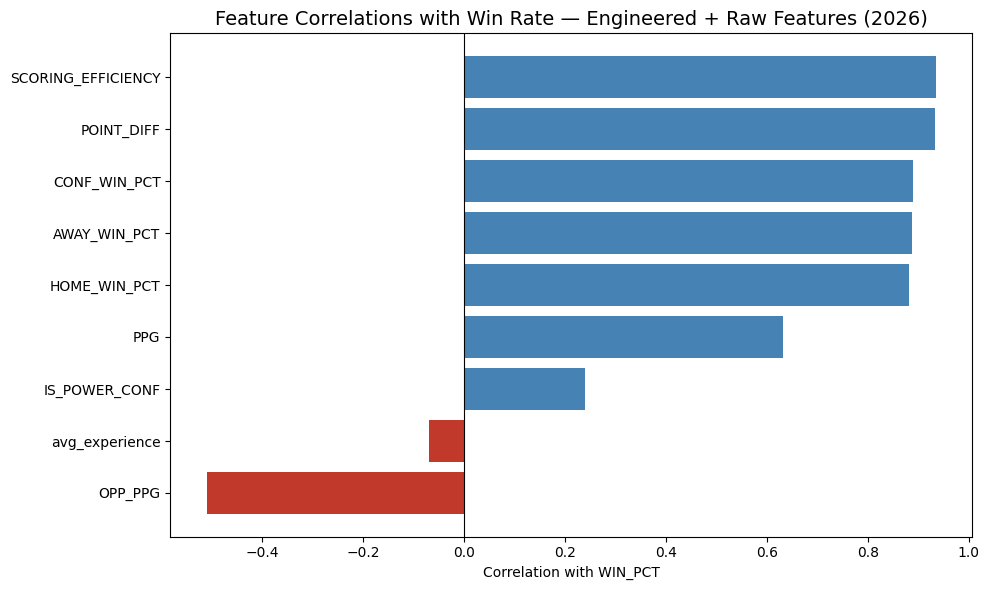

In [309]:
corr_cols_eng = ["WIN_PCT", "POINT_DIFF", "PPG", "OPP_PPG", 
                 "HOME_WIN_PCT", "AWAY_WIN_PCT", "CONF_WIN_PCT",
                 "SCORING_EFFICIENCY", "avg_experience", "IS_POWER_CONF"]

corr_eng = df_teams_exp[corr_cols_eng].corr()["WIN_PCT"].drop("WIN_PCT").sort_values()

fig, ax = plt.subplots(figsize=(10, 6))
colors = ["#c0392b" if x < 0 else "steelblue" for x in corr_eng]
ax.barh(corr_eng.index, corr_eng.values, color=colors)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_title("Feature Correlations with Win Rate — Engineered + Raw Features (2026)", fontsize=14)
ax.set_xlabel("Correlation with WIN_PCT")
plt.tight_layout()
plt.show()

The feature correlation chart confirms that our engineered features — scoring efficiency 
(0.94), home/away/conference win rates (0.87–0.89) — are the strongest predictors of 
win rate, outperforming raw stats like PPG (0.63) alone. Opp PPG is the only strongly 
negative predictor at -0.51. Roster experience (-0.07) and power conference membership 
(0.24) round out the feature set. These correlations directly inform which features 
enter the predictive models below.

### Model 1: Linear Regression — Predicting Season Win Rate

Target variable: `WIN_PCT`  
Features: scoring margin, home/away/conference win rates, scoring efficiency, 
PPG, opponent PPG, experience, and power conference flag — including both raw 
and engineered features.

In [310]:
features_lr = [
    "POINT_DIFF", "PPG", "OPP_PPG",
    "HOME_WIN_PCT", "AWAY_WIN_PCT", "CONF_WIN_PCT",
    "SCORING_EFFICIENCY", "avg_experience", "IS_POWER_CONF"
]
target_lr = "WIN_PCT"

df_model_lr = df_teams_exp[features_lr + [target_lr]].dropna()

X = df_model_lr[features_lr]
y = df_model_lr[target_lr]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred = lr.predict(X_test)

print(f"R²:   {r2_score(y_test, y_pred):.3f}")
print(f"MAE:  {mean_absolute_error(y_test, y_pred):.3f}")
print(f"MSE:  {mean_squared_error(y_test, y_pred):.3f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred)):.3f}")

R²:   0.978
MAE:  0.022
MSE:  0.001
RMSE: 0.027


In [311]:
coef_df = pd.DataFrame({
    "Feature": features_lr,
    "Coefficient": lr.coef_
}).sort_values("Coefficient", ascending=False).reset_index(drop=True)
coef_df

,Feature,Coefficient
0,HOME_WIN_PCT,0.397973
1,AWAY_WIN_PCT,0.367769
2,SCORING_EFFICIENCY,0.111807
3,IS_POWER_CONF,0.016337
4,PPG,0.002226
5,POINT_DIFF,0.001927
6,CONF_WIN_PCT,-0.000117
7,OPP_PPG,-0.002515
8,avg_experience,-0.006728


The coefficient table reinforces the EDA findings, but should be interpreted carefully because several inputs are themselves season-level performance measures. Home win rate (0.398) and away win rate (0.368) are the largest positive coefficients, suggesting that teams with more consistent performance across both home and road contexts tend to have higher overall win rates. Scoring efficiency (0.112) is the strongest scoring-based coefficient, consistent with the EDA finding that margin and efficiency are more informative than raw points alone. Average roster experience (-0.007) is negative and close to zero, which supports the earlier finding that experience alone does not meaningfully explain team success in this dataset.

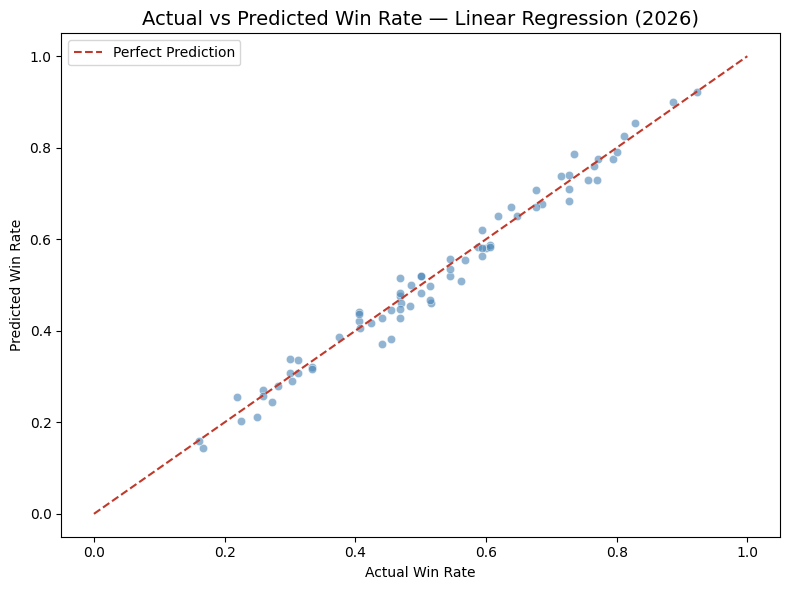

In [312]:
fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(y_test, y_pred, alpha=0.6, color="steelblue", edgecolors="white", linewidth=0.5)
ax.plot([0, 1], [0, 1], color="#c0392b", linestyle="--", linewidth=1.5, label="Perfect Prediction")
ax.set_title("Actual vs Predicted Win Rate — Linear Regression (2026)", fontsize=14)
ax.set_xlabel("Actual Win Rate")
ax.set_ylabel("Predicted Win Rate")
ax.legend()
plt.tight_layout()
plt.show()

The linear regression model explains 97.8% of the variance in season win rate (R² = 0.978) 
with a mean absolute error of just 2.2 percentage points — predicting a team's win rate 
to within about one win over a 33-game season. The actual vs predicted chart confirms 
the model performs consistently across the full range of win rates with no systematic 
bias toward over or underprediction.

### Model 2: Logistic Regression — Predicting Individual Game Outcomes

Target variable: `WON` (1 = win, 0 = loss)  
We build two versions of this model. Model 1 uses only game location as a feature — 
establishing a baseline that quantifies home court advantage alone. Model 2 adds 
team quality features to measure how much additional predictive power comes from 
knowing who is playing.

In [313]:
# encode location features
df_d1_games["HOME_AWAY_ENC"] = df_d1_games["HOME_AWAY"].map({"home": 1, "away": 0})
df_d1_games["NEUTRAL_SITE_ENC"] = df_d1_games["NEUTRAL_SITE"].astype(int)

# --- Model 1: location only ---
features_log1 = ["HOME_AWAY_ENC", "NEUTRAL_SITE_ENC"]
df_log1 = df_d1_games[features_log1 + ["WON"]].dropna()

X1 = df_log1[features_log1]
y1 = df_log1["WON"]

X_train1, X_test1, y_train1, y_test1 = train_test_split(X1, y1, test_size=0.2, random_state=42)

log1 = LogisticRegression(max_iter=1000)
log1.fit(X_train1, y_train1)
y_pred1 = log1.predict(X_test1)

print("--- Model 1: Location Only ---")
print(classification_report(y_test1, y_pred1))
print(f"Accuracy: {accuracy_score(y_test1, y_pred1):.3f}\n")

# --- Model 2: location + team quality ---
team_features = df_teams_exp[["TEAM_NAME", "WIN_PCT", "PPG", "OPP_PPG", 
                               "SCORING_EFFICIENCY", "IS_POWER_CONF", "avg_experience"]]
df_log2 = df_d1_games.merge(team_features, left_on="TEAM", right_on="TEAM_NAME", how="left")

features_log2 = ["HOME_AWAY_ENC", "NEUTRAL_SITE_ENC", "WIN_PCT", "PPG", 
                 "OPP_PPG", "SCORING_EFFICIENCY", "IS_POWER_CONF", "avg_experience"]
df_log2 = df_log2[features_log2 + ["WON"]].dropna()

X2 = df_log2[features_log2]
y2 = df_log2["WON"]

X_train2, X_test2, y_train2, y_test2 = train_test_split(X2, y2, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train2_scaled = scaler.fit_transform(X_train2)
X_test2_scaled = scaler.transform(X_test2)

log2 = LogisticRegression(max_iter=1000)
log2.fit(X_train2_scaled, y_train2)
y_pred2 = log2.predict(X_test2_scaled)

print("--- Model 2: Location + Team Quality ---")
print(classification_report(y_test2, y_pred2))
print(f"Accuracy: {accuracy_score(y_test2, y_pred2):.3f}")

--- Model 1: Location Only ---
              precision    recall  f1-score   support

           0       0.63      0.64      0.63      1128
           1       0.67      0.66      0.66      1263

    accuracy                           0.65      2391
   macro avg       0.65      0.65      0.65      2391
weighted avg       0.65      0.65      0.65      2391

Accuracy: 0.649

--- Model 2: Location + Team Quality ---
              precision    recall  f1-score   support

           0       0.66      0.66      0.66      1128
           1       0.70      0.70      0.70      1263

    accuracy                           0.68      2391
   macro avg       0.68      0.68      0.68      2391
weighted avg       0.68      0.68      0.68      2391

Accuracy: 0.681


In [314]:
y_prob1 = log1.predict_proba(X_test1)[:, 1]
print(f"Model 1 ROC AUC: {roc_auc_score(y_test1, y_prob1):.3f}")

y_prob2 = log2.predict_proba(X_test2_scaled)[:, 1]
print(f"Model 2 ROC AUC: {roc_auc_score(y_test2, y_prob2):.3f}")

Model 1 ROC AUC: 0.650
Model 2 ROC AUC: 0.748


The ROC AUC scores reveal an important distinction between the two models. Model 1, using only game location, achieves a ROC AUC of 0.650 — meaningfully better than random but limited by the single signal of home court advantage. Model 2, adding team quality features, improves to 0.748, suggesting that team strength adds meaningful predictive power beyond location alone. The 0.098 AUC improvement is larger than the 3.2 percentage point accuracy gain, suggesting that team quality features improve the model’s ability to rank predictions by confidence, not just classify wins and losses.

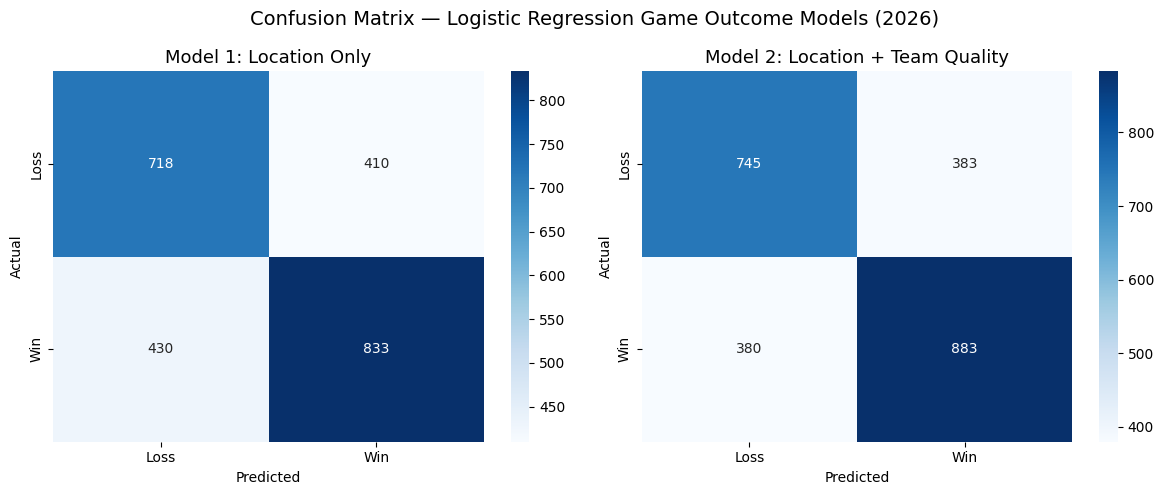

In [315]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, y_pred, title in zip(axes, [y_pred1, y_pred2], 
                              ["Model 1: Location Only", "Model 2: Location + Team Quality"]):
    cm = confusion_matrix(y_test1 if title == "Model 1: Location Only" else y_test2, y_pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
                xticklabels=["Loss", "Win"], yticklabels=["Loss", "Win"])
    ax.set_title(title, fontsize=13)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

plt.suptitle("Confusion Matrix — Logistic Regression Game Outcome Models (2026)", fontsize=14)
plt.tight_layout()
plt.show()

In [316]:
model_summary = pd.DataFrame({
    "Model": ["Location Only", "Location + Team Quality"],
    "Features": ["Home/Away, Neutral Site", 
                 "Home/Away, Neutral Site, Win Rate, PPG, Opp PPG, Scoring Efficiency, Power Conf, Experience"],
    "Accuracy": [0.649, 0.681],
    "ROC AUC": [0.650, 0.748],
    "F1 (Win)": [0.66, 0.70],
    "F1 (Loss)": [0.63, 0.66]
})
model_summary

,Model,Features,Accuracy,ROC AUC,F1 (Win),F1 (Loss)
0,Location Only,"Home/Away, Neutral Site",0.649,0.650,0.66,0.63
1,Location + Team Quality,"Home/Away, Neutral Site, Win Rate, PPG, Opp PP...",0.681,0.748,0.70,0.66


Model 1, using only game location, achieves 64.9% accuracy and a ROC AUC of 0.650. Model 2, adding team quality features, improves to 68.1% accuracy and a ROC AUC of 0.748. The 3.2 percentage point accuracy gain and 0.098 AUC improvement show that team quality features add meaningful predictive power beyond location alone.

## Section 8: Conclusion and Future Work

This analysis examined the 2025–26 NCAA Division I men’s basketball season across 362 programs, representing 6,292 unique games, and 5,648 rostered players. The central question was: what separates winning programs in D1 basketball? The evidence points to a consistent story: scoring margin, situational win rates, and conference context are the clearest measurable signals of team strength, while roster experience provides useful context but does not meaningfully explain winning on its own. For athletic departments, conference offices, or sports analytics staff, this means win-loss record alone is an incomplete measure of team quality; programs should benchmark themselves against peers with similar scoring margins, road performance, and conference context, not just teams with similar records.

### Key Findings

1. **Scoring margin is the clearest signal of team strength.**
Point differential correlates at 0.93 with win rate, stronger than raw points scored or points allowed alone. Teams that consistently outscore opponents by larger margins tend to win more games, making margin a more informative measure than record alone.

2. **Power conferences perform better on average, but basketball strength extends beyond the Power 4.**
The Big 12, SEC, ACC, and Big Ten all sit above the D1 mean win rate of 0.52. However, basketball-heavy leagues outside that group, including the Big East and Atlantic 10, also show strong performance, suggesting that conference context matters but cannot be reduced to a simple power versus mid-major split.

3. **Home court advantage is real and quantifiable.**
Home teams win 67.9% of games compared with 35.6% for away teams, while neutral-site games are close to evenly split at 50.2%. Location alone predicts individual game outcomes at 64.9% accuracy.

4. **The AP poll validates the internal performance metrics.**
Ranked teams average a 0.769 win rate and +11.72 point differential compared with 0.498 and +0.91 for unranked teams. This suggests that the internal metrics align with an external benchmark of team quality.

5. **Roster experience alone does not predict winning.**
Average roster experience has a correlation of -0.071 with win rate, meaning it has almost no relationship with team success in this dataset. More detailed player production, recruiting, and transfer data would be needed to evaluate roster quality more directly.

6. **The models confirm the EDA, but should be interpreted carefully.**
The linear regression explains 97.8% of variation in season win rate using engineered performance features. The logistic regression improves from 64.9% accuracy using location alone to 68.1% accuracy when season-level team quality features are added. Because those team quality features are calculated across the season, the game model should be interpreted as explanatory rather than a true pre-game forecasting model.

### Recommendations for Athletic Department Strategy Teams

The findings from this analysis point to three practical ways athletic departments, conference offices, and basketball operations staff can evaluate program strength:

1. **Evaluate margin, not just wins** — win-loss record alone can hide meaningful differences between teams with similar records. Point differential and scoring efficiency provide a clearer view of underlying team strength because they capture how convincingly a team wins or loses, not just whether it won.

2. **Use road performance as a key stress test** — home court advantage is one of the strongest patterns in the data, so road performance is especially useful for evaluating whether a team’s success travels beyond its home environment. Programs that win consistently away from home may have more sustainable performance than teams whose records depend heavily on home wins.

3. **Do not over-index on roster experience alone** — average roster experience has little relationship with winning in this dataset. That does not mean continuity is unimportant, but it suggests that experience by itself is too limited a measure of roster quality. Future evaluations should pair experience with player production, transfer history, recruiting quality, and minutes played.

### Limitations

- **Single season**: This analysis covers only the 2025–26 season. Multi-year data would 
  allow trend analysis and more robust modeling.
- **No strength of schedule adjustment**: Win rates are not adjusted for opponent quality, 
  meaning a 20-win team in a weak conference is treated the same as a 20-win team in the SEC.
- **Roster data completeness**: Weight (4.9%) and other player attributes are missing for 
  some players, limiting the depth of physical profile analysis.

### Future Work

If more time were available, the next steps would be:
- Incorporate NCAA tournament seeding and outcomes to evaluate which regular season 
  metrics predict March success
- Add KenPom or BartTorvik efficiency ratings as an external benchmark
- Build a strength of schedule adjustment to make cross-conference comparisons more meaningful
- Expand to multiple seasons to identify program trajectory and trend analysis
- Explore clustering models to identify program archetypes across the D1 landscape

## Appendix

In [317]:
df_d1_teams.head()

,TEAM_ID,SEASON,TEAM_NAME,ABBREVIATION,LOCATION,MASCOT,CONFERENCE,DIVISION,WINS,LOSSES,...,CONF_WINS,CONF_LOSSES,IS_POWER_CONF,SCORING_EFFICIENCY,HOME_WIN_PCT,AWAY_WIN_PCT,CONF_WIN_PCT,AP_RANK,AP_POINTS,IS_RANKED
0,2,2026,Auburn Tigers,AUB,Auburn,Tigers,Southeastern Conference,NCAA Division I,22.0,16.0,...,7.0,11.0,1,1.054,0.778,0.200,0.389,NaN,NaN,0
1,5,2026,UAB Blazers,UAB,UAB,Blazers,American Conference,NCAA Division I,20.0,12.0,...,11.0,7.0,0,1.074,0.471,0.833,0.611,NaN,NaN,0
2,6,2026,South Alabama Jaguars,USA,South Alabama,Jaguars,Sun Belt Conference,NCAA Division I,21.0,12.0,...,11.0,7.0,0,1.061,0.714,0.533,0.611,NaN,NaN,0
3,8,2026,Arkansas Razorbacks,ARK,Arkansas,Razorbacks,Southeastern Conference,NCAA Division I,28.0,9.0,...,13.0,5.0,1,1.113,0.944,0.500,0.722,13.0,716.0,1
4,9,2026,Arizona State Sun Devils,ASU,Arizona State,Sun Devils,Big 12 Conference,NCAA Division I,17.0,16.0,...,7.0,11.0,1,0.974,0.667,0.182,0.389,NaN,NaN,0


In [318]:
df_d1_players.head()

,ATHLETE_ID,TEAM_ID,SEASON,TEAM_NAME,CONFERENCE,PLAYER_NAME,FIRST_NAME,LAST_NAME,JERSEY,POSITION,POSITION_NAME,HEIGHT,WEIGHT,YEAR,YEARS_EXP,CITY,STATE,COUNTRY,ACTIVE,POSITION_FULL
0,5311501,2,2026,Auburn Tigers,Southeastern Conference,Abdul Bashir,Abdul,Bashir,2,G,Guard,79.0,165.0,Junior,3.0,Omaha,NE,USA,True,Guard
1,5311504,2,2026,Auburn Tigers,Southeastern Conference,Jeremiah Bowman,Jeremiah,Bowman,20,G,Guard,79.0,205.0,Freshman,1.0,Glassboro,NJ,USA,True,Guard
2,5238198,2,2026,Auburn Tigers,Southeastern Conference,Drake Cardwell,Drake,Cardwell,17,G,Guard,77.0,195.0,Sophomore,2.0,Augusta,GA,USA,True,Guard
3,5311502,2,2026,Auburn Tigers,Southeastern Conference,Elyjah Freeman,Elyjah,Freeman,6,G,Guard,80.0,185.0,Sophomore,2.0,Palm Beach,FL,USA,True,Guard
4,5075625,2,2026,Auburn Tigers,Southeastern Conference,Keyshawn Hall,Keyshawn,Hall,7,F,Forward,79.0,225.0,Senior,4.0,Cleveland,OH,USA,True,Forward


In [319]:
df_d1_games.head()

,TEAM_ID,SEASON,SEASON_TYPE,TEAM,CONFERENCE,GAME_ID,GAME_DATE,OPPONENT_ID,OPPONENT,HOME_AWAY,NEUTRAL_SITE,ATTENDANCE,WON,TEAM_SCORE,OPP_SCORE,SCORE_MARGIN,LOCATION,HOME_AWAY_ENC,NEUTRAL_SITE_ENC
0,311,2026,2,Maine Black Bears,America East Conference,401820631,2025-12-21 19:00:00,2182,Drexel Dragons,away,False,796,0,56,74,-18,Away,0,0
1,311,2026,2,Maine Black Bears,America East Conference,401812115,2026-01-10 19:00:00,2885,NJIT Highlanders,away,False,343,1,74,70,4,Away,0,0
2,326,2026,2,Texas State Bobcats,Sun Belt Conference,401823415,2025-11-04 00:00:00,189,Bowling Green Falcons,away,False,3003,0,48,83,-35,Away,0,0
3,326,2026,2,Texas State Bobcats,Sun Belt Conference,401827214,2025-11-25 00:00:00,2639,Texas Lutheran Bulldogs,home,False,1287,1,93,41,52,Home,1,0
4,326,2026,2,Texas State Bobcats,Sun Belt Conference,401808611,2026-01-10 20:00:00,2032,Arkansas State Red Wolves,away,False,4059,0,82,83,-1,Away,0,0


In [320]:
df_d1_games_unique.head()

,GAME_ID,SEASON,SEASON_TYPE,GAME_DATE,TEAM_1_ID,TEAM_1,TEAM_1_SCORE,TEAM_2_ID,TEAM_2,TEAM_2_SCORE,SCORE_MARGIN
0,401804831,2026,2,2025-12-28 19:00:00,2229,Florida International Panthers,94,2335,Liberty Flames,97,3
1,401804856,2026,2,2026-01-03 01:00:00,2623,Missouri State Bears,79,2638,UTEP Miners,55,24
2,401804870,2026,2,2026-01-09 02:00:00,2393,Middle Tennessee Blue Raiders,80,2638,UTEP Miners,83,3
3,401804875,2026,2,2026-01-11 01:00:00,166,New Mexico State Aggies,55,2393,Middle Tennessee Blue Raiders,59,4
4,401804885,2026,2,2026-01-17 19:00:00,166,New Mexico State Aggies,97,48,Delaware Blue Hens,68,29
